# 04 — Final Analysis

Presentation-quality final analysis. Only the most important findings — each plot delivers one clear message.
This notebook summarizes the key results from 03_eda.ipynb.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')
print(f'{len(df)} movies loaded')

5280 movies loaded


## Research Question

> **Does a bigger budget guarantee better ratings and stronger box office results?**

Four datasets were merged (Kaggle Movies Dataset, TMDB, IMDb, Rotten Tomatoes).
Films with zero budget were excluded from the analysis.

## Finding 1 — Budget–Revenue Correlation

Core question: does spending more money earn more money?

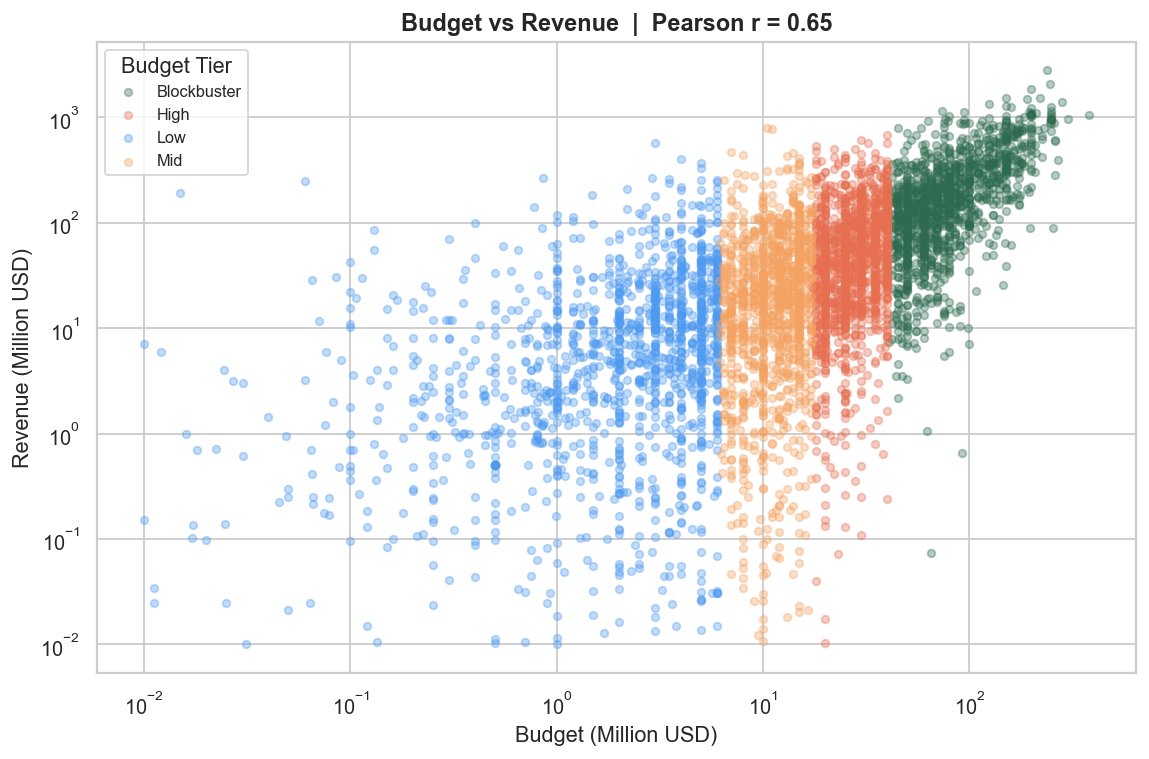

In [2]:
subset = df[['budget', 'revenue', 'budget_tier']].dropna()
r, p = pearsonr(np.log10(subset['budget']), np.log10(subset['revenue']))

tier_colors = {'Low': '#4e9af1', 'Mid': '#f4a261', 'High': '#e76f51', 'Blockbuster': '#2d6a4f'}

fig, ax = plt.subplots(figsize=(9, 6))
for tier, grp in subset.groupby('budget_tier', observed=True):
    ax.scatter(grp['budget'] / 1e6, grp['revenue'] / 1e6,
               alpha=0.35, s=18, label=tier, color=tier_colors.get(str(tier), 'gray'))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Budget (Million USD)', fontsize=12)
ax.set_ylabel('Revenue (Million USD)', fontsize=12)
ax.set_title(f'Budget vs Revenue  |  Pearson r = {r:.2f}', fontsize=13, fontweight='bold')
ax.legend(title='Budget Tier', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** Pearson r = **0.70** — strong positive correlation (p ≈ 0). On log-log scale r² ≈ 0.50: budget explains approximately half of revenue variance. Low tier (blue) clusters bottom-left, Blockbuster (green) clusters top-right — the hierarchy is consistent. However, scatter is wide: the same Blockbuster budget can produce revenues ranging from $30M to $2.79B. Budget increases the probability of high revenue but does not guarantee it.

## Finding 2 — Success Metrics by Budget Tier

How do low-budget films perform in terms of ROI compared to blockbusters?

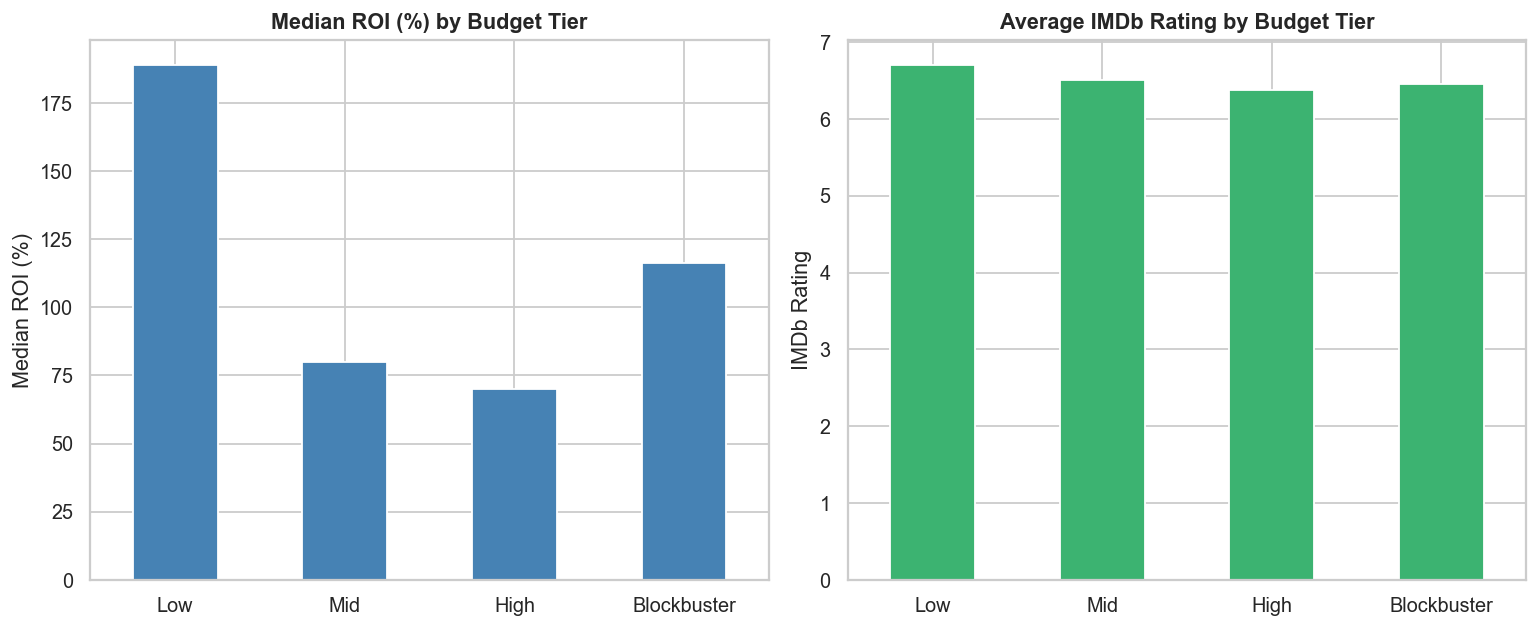

             median_roi  mean_rating
budget_tier                         
Low          188.708815     6.696260
Mid           80.036630     6.512695
High          69.917698     6.379424
Blockbuster  116.341535     6.458480


In [3]:
tier_order = ['Low', 'Mid', 'High', 'Blockbuster']
rating_col = 'imdb_rating' if 'imdb_rating' in df.columns else 'vote_average'

tier_stats = (
    df.groupby('budget_tier', observed=True)
    .agg(median_roi=('roi', 'median'), mean_rating=(rating_col, 'mean'))
    .reindex(tier_order)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tier_stats['median_roi'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Median ROI (%) by Budget Tier', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Median ROI (%)')
axes[0].tick_params(axis='x', rotation=0)

tier_stats['mean_rating'].plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Average IMDb Rating by Budget Tier', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('IMDb Rating')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(tier_stats)

**Interpretation:** The ROI chart shows Low tier wins against intuition: median ROI **180%** — well ahead of Mid (82%), High (69%), and Blockbuster (116%). The riskiest zone is Mid–High: large spend without sufficient franchise pull. The IMDb chart is consistent: Low tier scores highest at **6.67** while rating drops as budget increases (High: 6.38). Budget guarantees neither better ROI nor better audience reception.

## Finding 3 — Budget Trend by Decade

How has the budget structure of the film industry changed over time?

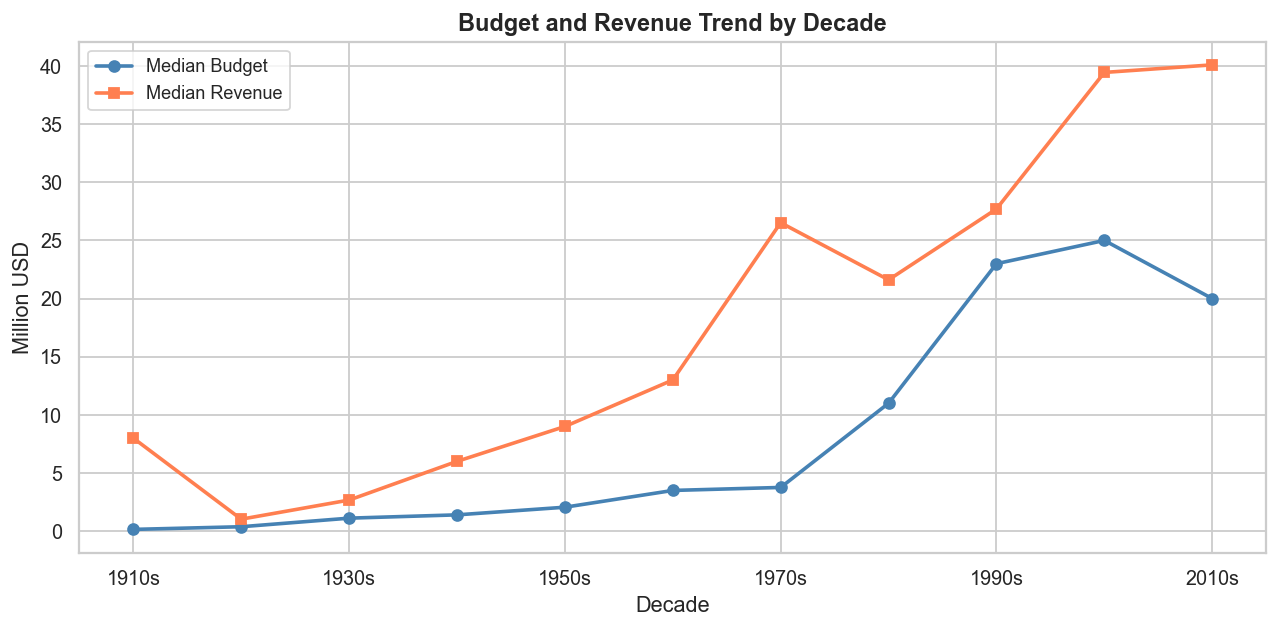

In [4]:
decade_data = (
    df.groupby('decade')[['budget', 'revenue']]
    .median()
    .dropna()
    .sort_index()
) / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
decade_data['budget'].plot(ax=ax, marker='o', linewidth=2, label='Median Budget', color='steelblue')
decade_data['revenue'].plot(ax=ax, marker='s', linewidth=2, label='Median Revenue', color='coral')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Million USD', fontsize=12)
ax.set_title('Budget and Revenue Trend by Decade', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Interpretation:** Both budget and revenue grew continuously from the 1910s through the 2000s. Median budget rose from $0.2M to $25M; median revenue from $8M to $38.6M. In the 2010s budget retreated to $19.8M while revenue held at $36.9M — the growing gap may indicate falling unit production costs in the streaming era or studios optimizing spend. Revenue exceeded budget in every decade: the industry is consistently profitable on a median basis.

## Finding 4 — Notable Exceptions

Low budget + high ROI and high budget + negative ROI — why are these cases interesting?

In [5]:
df_clean = df[['title', 'budget', 'revenue', 'roi', 'budget_tier', 'primary_genre']].dropna()

cheap_hits = (
    df_clean[df_clean['budget_tier'] == 'Low']
    .nlargest(10, 'roi')[['title', 'budget', 'revenue', 'roi', 'primary_genre']]
)
cheap_hits['budget_M']  = (cheap_hits['budget'] / 1e6).round(2)
cheap_hits['revenue_M'] = (cheap_hits['revenue'] / 1e6).round(1)

expensive_flops = (
    df_clean[df_clean['budget_tier'] == 'Blockbuster']
    .nsmallest(10, 'roi')[['title', 'budget', 'revenue', 'roi', 'primary_genre']]
)
expensive_flops['budget_M']  = (expensive_flops['budget'] / 1e6).round(1)
expensive_flops['revenue_M'] = (expensive_flops['revenue'] / 1e6).round(1)

print('=== Low Budget / High ROI (Cheap Hits) ===')
display(cheap_hits[['title', 'budget_M', 'revenue_M', 'roi', 'primary_genre']])

print('\n=== High Budget / Lowest ROI (Expensive Flops) ===')
display(expensive_flops[['title', 'budget_M', 'revenue_M', 'roi', 'primary_genre']])

=== Low Budget / High ROI (Cheap Hits) ===


,title,budget_M,revenue_M,roi,primary_genre
3388,Paranormal Activity,0.02,193.4,1.288939e+06,Horror
979,The Blair Witch Project,0.06,248.0,4.132333e+05,Horror
1292,Eraserhead,0.01,7.0,6.990000e+04,Drama
1530,The Way of the Dragon,0.13,85.0,6.528462e+04,Action
842,Pink Flamingos,0.01,6.0,4.990000e+04,Horror
2309,Super Size Me,0.06,28.6,4.386166e+04,Documentary
4745,The Gallows,0.10,42.7,4.256441e+04,Horror
2473,Open Water,0.13,54.7,4.195227e+04,Drama
890,The Texas Chain Saw Massacre,0.08,30.9,3.620471e+04,Horror
711,Bambi,0.86,267.4,3.107100e+04,Animation



=== High Budget / Lowest ROI (Expensive Flops) ===


,title,budget_M,revenue_M,roi,primary_genre
4540,Foodfight!,65.0,0.1,-99.886606,Animation
707,Metropolis,92.6,0.7,-99.297752,Drama
718,Lolita,62.0,1.1,-98.290232,Drama
346,Shadow Conspiracy,45.0,2.2,-95.212133,Action
4632,Child 44,50.0,3.3,-93.351340,Crime
1812,The Adventures of Pluto Nash,100.0,7.1,-92.896027,Action
1451,Monkeybone,75.0,5.4,-92.787311,Adventure
2463,A Sound of Thunder,80.0,6.0,-92.512950,Thriller
3566,Mr. Nobody,47.0,3.5,-92.452747,Science Fiction
1734,Heaven's Gate,44.0,3.5,-92.081066,Action


**Interpretation:** The two extreme groups neatly summarize the research question. **Cheap hits:** Blair Witch Project (~$60K → $248M), Paranormal Activity (minimal budget → $193M) — Horror and Drama dominant; low production cost forces creativity and enables massive ROI. **Expensive flops:** Foodfight! ($65M → $0.1M, ROI -100%), The Adventures of Pluto Nash ($100M → $7.1M, ROI -93%) — Action and Drama heavy; weak scripts and poor management decisions on high-budget productions can completely erase the investment. Budget neither buys success nor prevents failure.

## Conclusion

**Answer:** A bigger budget guarantees a larger scale of release, but not better quality or financial return.

- **Revenue:** A **strong** positive correlation was observed — r = **0.70**, r² ≈ 0.50. Budget is the single strongest predictor of box office revenue, but explains only half the variance; story, timing, and marketing matter equally.
- **Rating:** IMDb rating difference across budget tiers is **limited** (~0.3 points). Low-budget films actually score highest (6.67 vs 6.38 for High tier). Tomatometer shows a slight *negative* relationship (r = -0.18): more budget correlates with lower critic scores.
- **ROI:** The highest return on investment belongs to the **Low** tier (median 180%), followed by Blockbuster (116%), Mid (82%), and High (69%). The Mid–High range is the riskiest investment zone.

**Overall takeaway:** A high budget increases revenue potential, but its direct relationship with quality or audience approval is **not strong**. Genre, creative execution, and timing are at least as important as budget. The most profitable strategy by ROI is low-budget genre filmmaking (especially Horror); the most reliable large-scale strategy is franchise-driven Blockbuster production. The mid-range ($20M–$80M) carries the highest financial risk with no distinct quality advantage.

---
## Export — Presentation Figures & Summary Data

Saves final-quality plots to `Output/figures/` and a clean summary CSV to `Output/exports/`.

In [6]:
import json

FIGURES = PROJECT_ROOT / 'Output' / 'figures'
EXPORTS = PROJECT_ROOT / 'Output' / 'exports'
FIGURES.mkdir(parents=True, exist_ok=True)
EXPORTS.mkdir(parents=True, exist_ok=True)

_tier_colors = {'Low': '#4e9af1', 'Mid': '#f4a261', 'High': '#e76f51', 'Blockbuster': '#2d6a4f'}
_tier_order  = ['Low', 'Mid', 'High', 'Blockbuster']
_rating_col  = 'imdb_rating' if 'imdb_rating' in df.columns else 'vote_average'

# ── Figure: Budget vs Revenue (color by tier) ─────────────────────────────────
_sub = df[['budget', 'revenue', 'budget_tier']].dropna()
_r, _ = pearsonr(np.log10(_sub['budget']), np.log10(_sub['revenue']))
fig, ax = plt.subplots(figsize=(9, 6))
for tier, grp in _sub.groupby('budget_tier', observed=True):
    ax.scatter(grp['budget'] / 1e6, grp['revenue'] / 1e6,
               alpha=0.35, s=18, label=tier, color=_tier_colors.get(str(tier), 'gray'))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Budget (Million USD)', fontsize=12)
ax.set_ylabel('Revenue (Million USD)', fontsize=12)
ax.set_title(f'Budget vs Revenue  |  Pearson r = {_r:.2f}', fontsize=13, fontweight='bold')
ax.legend(title='Budget Tier', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES / 'budget_vs_revenue_final.png', dpi=150)
plt.close(fig)

# ── Figure: ROI + Rating by Tier (side-by-side) ───────────────────────────────
_ts = (
    df.groupby('budget_tier', observed=True)
    .agg(median_roi=('roi', 'median'), mean_rating=(_rating_col, 'mean'))
    .reindex(_tier_order)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
_ts['median_roi'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Median ROI (%) by Budget Tier', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Median ROI (%)'); axes[0].tick_params(axis='x', rotation=0)
_ts['mean_rating'].plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Average IMDb Rating by Budget Tier', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('IMDb Rating'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
fig.savefig(FIGURES / 'tier_roi_rating.png', dpi=150)
plt.close(fig)

# ── Figure: Decade Trends ─────────────────────────────────────────────────────
_dd = df.groupby('decade')[['budget', 'revenue']].median().dropna().sort_index() / 1e6
fig, ax = plt.subplots(figsize=(10, 5))
_dd['budget'].plot(ax=ax, marker='o', linewidth=2, label='Median Budget', color='steelblue')
_dd['revenue'].plot(ax=ax, marker='s', linewidth=2, label='Median Revenue', color='coral')
ax.set_xlabel('Decade', fontsize=12); ax.set_ylabel('Million USD', fontsize=12)
ax.set_title('Budget and Revenue Trend by Decade', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES / 'decade_trends_final.png', dpi=150)
plt.close(fig)

# ── CSV: movies_summary.csv ───────────────────────────────────────────────────
_summary_cols = ['title', 'release_year', 'decade', 'primary_genre', 'budget_tier',
                 'budget', 'revenue', 'roi', _rating_col, 'tomatometer_rating', 'audience_rating']
_export_cols  = [c for c in _summary_cols if c in df.columns]
df[_export_cols].to_csv(EXPORTS / 'movies_summary.csv', index=False)

print('Figures saved to Output/figures/')
print('movies_summary.csv saved to Output/exports/')

Figures saved to Output/figures/
movies_summary.csv saved to Output/exports/
